# Disparities in Suspect Identification: Analyzing Demographic Variation in NYPD Investigation Data

## Objective
This notebook performs an **extensive, senior-level analysis** of the NYPD Shooting Incident Dataset. Our goal is to uncover systemic disparities in suspect identification rates.

### Key Inquiries:
1.  **Descriptive Analytics**: Detailed statistical overview of the dataset.
2.  **Demographic Disparities**: Are suspects less likely to be identified when the victim belongs to a specific demographic group?
3.  **Geospatial & Temporal Patterns**: Using GeoJSON precinct maps to visualize 'unsolved zones'.
4.  **Advanced Causal Inference**: 
    *   **Logistic Regression Odds Ratios**: Quantifying likelihoods.
    *   **Inequality Metrics**: Gini Coefficients for investigative equity.
    *   **Counterfactual Analysis**: Comparing solvability probabilities across *all* victim race permutations.
5.  **Predictive Modeling (Robust & GPU Accelerated)**: Using XGBoost & Deep Autoencoders to predict solvability and explain it using **SHAP** values.

**Hardware**: Optimized for NVIDIA GPUs (RTX 3050 Ti).

In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
from scipy.stats import chi2_contingency
import warnings
import re # For sanitizing column names

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('dark_background') 

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. Data Loading, Cleaning & Advanced Feature Engineering

In [24]:
# Load Data
try:
    df = pd.read_csv('../Dataset/NYPD_Shooting_Incident_Data__Historic_.csv')
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset file not found. Please check the path.")

# Basic Cleaning
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'], errors='coerce')
df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S', errors='coerce').dt.time
df['OCCUR_DATETIME'] = pd.to_datetime(df['OCCUR_DATE'].astype(str) + ' ' + df['OCCUR_TIME'].astype(str))

# Target Variable: Suspect Identified?
def is_identified(row):
    if pd.isna(row['PERP_RACE']) or row['PERP_RACE'] == 'UNKNOWN':
        return 0
    return 1
df['Suspect_Identified'] = df.apply(is_identified, axis=1)

# --- Advanced Feature Engineering ---

# 1. Temporal Features
df['Year'] = df['OCCUR_DATETIME'].dt.year
df['Month'] = df['OCCUR_DATETIME'].dt.month
df['DayOfWeek'] = df['OCCUR_DATETIME'].dt.day_name()
df['Hour'] = df['OCCUR_DATETIME'].dt.hour
df['Is_Weekend'] = (df['OCCUR_DATETIME'].dt.weekday >= 5).astype(int)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
df['Season'] = df['Month'].apply(get_season)

def get_time_period(hour):
    if 6 <= hour < 12: return 'Morning'
    elif 12 <= hour < 18: return 'Afternoon'
    elif 18 <= hour < 24: return 'Evening'
    else: return 'Night'
df['Time_Period'] = df['Hour'].apply(get_time_period)

# 2. Demographic Aggregations
# Simplify Race for clearer analysis
def simplify_race(race):
    if isinstance(race, str):
        if 'BLACK' in race: return 'Black'
        if 'WHITE' in race and 'HISPANIC' not in race: return 'White'
        if 'HISPANIC' in race: return 'Hispanic'
        if 'ASIAN' in race: return 'Asian'
    return 'Other/Unknown'

df['Vic_Race_Simple'] = df['VIC_RACE'].apply(simplify_race)
df['Minority_Victim'] = df['Vic_Race_Simple'].isin(['Black', 'Hispanic']).astype(int)

# 3. Precinct Safety Score (Resource Strain Proxy)
# Rolling count of incidents in the last 30 days per precinct
df = df.sort_values('OCCUR_DATETIME')
df['Precinct_Rolling_Incidents'] = df.groupby('PRECINCT')['INCIDENT_KEY'].transform(
    lambda x: x.rolling(window=30, min_periods=1).count()
)

# Fill Missing
valid_age_groups = ['<18', '18-24', '25-44', '45-64', '65+']
for col in ['VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE']:
    df[col] = df[col].fillna('UNKNOWN')
    
df_clean = df.dropna(subset=['Latitude', 'Longitude']).copy()
print(f"Data prepared. Final Shape: {df_clean.shape}")

Dataset loaded successfully. Shape: (27312, 21)
Data prepared. Final Shape: (27302, 33)


## 2. Descriptive Statistics & Baseline Analysis (Detailed)

In [25]:
# Formatted Descriptive Statistics Table
from IPython.display import display, HTML

# 1. Numeric Summary
numeric_stats = df_clean[['Latitude', 'Longitude', 'Year', 'Hour', 'Precinct_Rolling_Incidents']].describe().T
print("### 1. Numeric Feature Statistics")
display(numeric_stats)

# 2. Categorical Summary (Top values)
cat_cols = ['BORO', 'Vic_Race_Simple', 'VIC_SEX', 'VIC_AGE_GROUP', 'Time_Period']
cat_stats = df_clean[cat_cols].describe().T
print("\n### 2. Categorical Feature Summary")
display(cat_stats)

# 3. Target Distribution
target_dist = df_clean['Suspect_Identified'].value_counts(normalize=True).to_frame(name='Proportion')
target_dist['Count'] = df_clean['Suspect_Identified'].value_counts()
print("\n### 3. Target Variable Distribution (Suspect Identified)")
display(target_dist)

### 1. Numeric Feature Statistics


,count,mean,std,min,25%,50%,75%,max
Latitude,27302.0,40.737892,0.087525,40.511586,40.668481,40.700318,40.824067,40.910818
Longitude,27302.0,-73.909051,0.066272,-74.249303,-73.943027,-73.915221,-73.882330,-73.702046
Year,27302.0,2013.489378,5.141450,2006.000000,2009.000000,2013.000000,2018.000000,2022.000000
Hour,27302.0,12.222731,8.485516,0.000000,3.000000,15.000000,20.000000,23.000000
Precinct_Rolling_Incidents,27302.0,28.804080,4.715203,1.000000,30.000000,30.000000,30.000000,30.000000



### 2. Categorical Feature Summary


,count,unique,top,freq
BORO,27302,5,BROOKLYN,10929
Vic_Race_Simple,27302,5,Black,22077
VIC_SEX,27302,3,M,24678
VIC_AGE_GROUP,27302,7,25-44,12276
Time_Period,27302,4,Evening,10841



### 3. Target Variable Distribution (Suspect Identified)


,Proportion,Count
Suspect_Identified,,
1,0.591752,16156
0,0.408248,11146


## 3. Extended EDA: Disparities & Multivariate Analysis

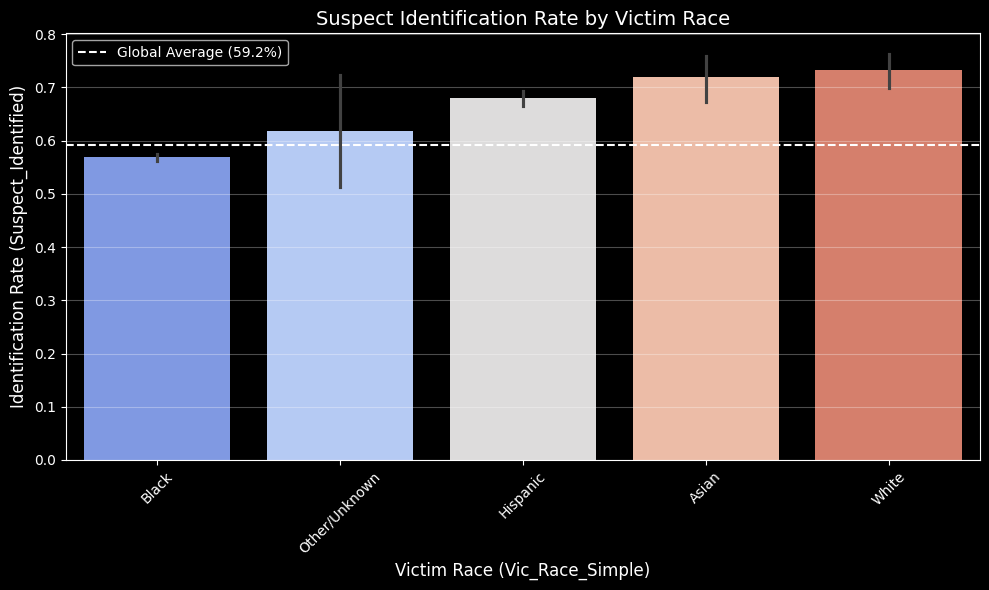

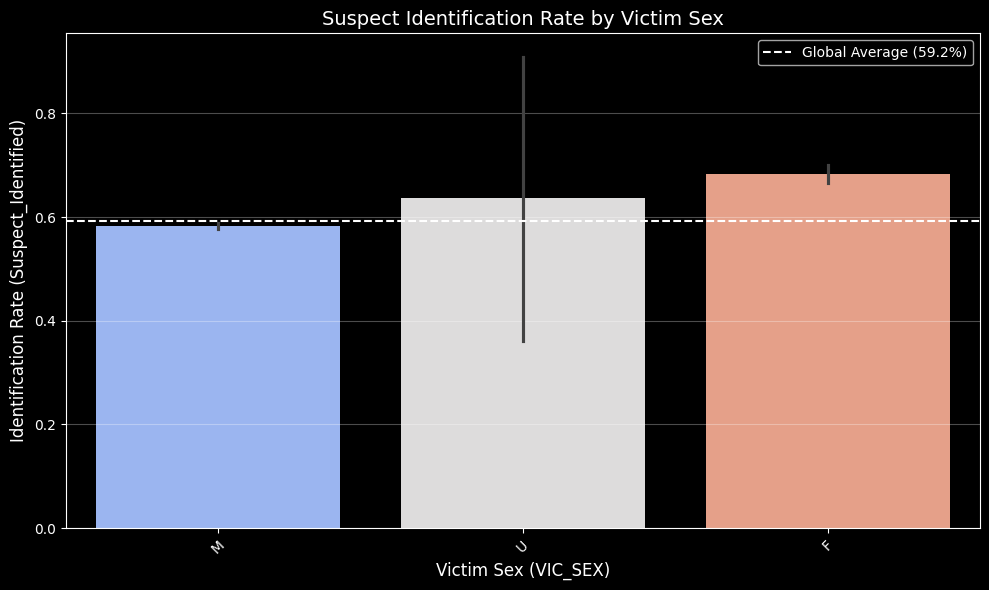

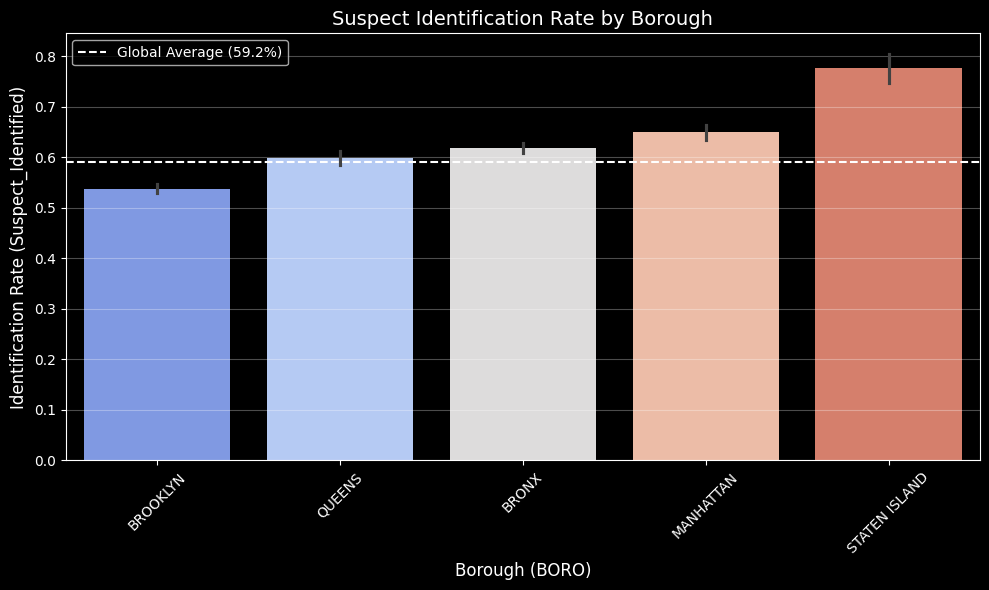

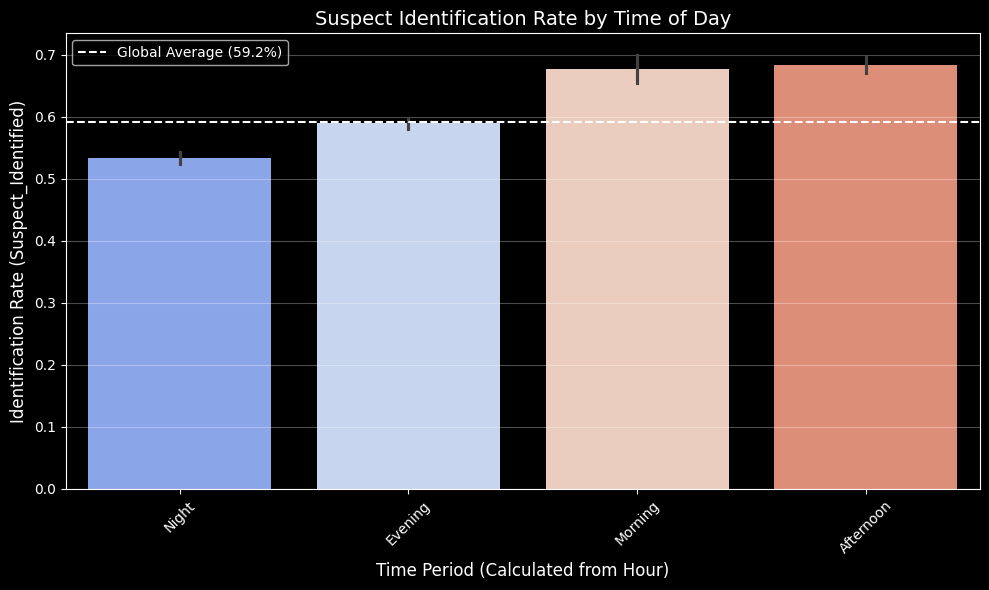

In [26]:
# 3.1 Visualizing Identification Rates (Separate Figures, Clean Labels)

plot_configs = [
    {'col': 'Vic_Race_Simple', 'title': 'Suspect Identification Rate by Victim Race', 'xlabel': 'Victim Race (Vic_Race_Simple)'},
    {'col': 'VIC_SEX', 'title': 'Suspect Identification Rate by Victim Sex', 'xlabel': 'Victim Sex (VIC_SEX)'},
    {'col': 'BORO', 'title': 'Suspect Identification Rate by Borough', 'xlabel': 'Borough (BORO)'},
    {'col': 'Time_Period', 'title': 'Suspect Identification Rate by Time of Day', 'xlabel': 'Time Period (Calculated from Hour)'}
]

for config in plot_configs:
    plt.figure(figsize=(10, 6))
    col = config['col']
    order = df_clean.groupby(col)['Suspect_Identified'].mean().sort_values().index
    
    # Calculate Mean
    mean_val = df_clean['Suspect_Identified'].mean()
    
    # Bar Plot
    sns.barplot(x=col, y='Suspect_Identified', data=df_clean, order=order, palette='coolwarm')
    
    # Aesthetics
    plt.title(config['title'], fontsize=14)
    plt.xlabel(config['xlabel'], fontsize=12)
    plt.ylabel("Identification Rate (Suspect_Identified)", fontsize=12)
    plt.axhline(mean_val, color='white', linestyle='--', label=f'Global Average ({mean_val:.1%})')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

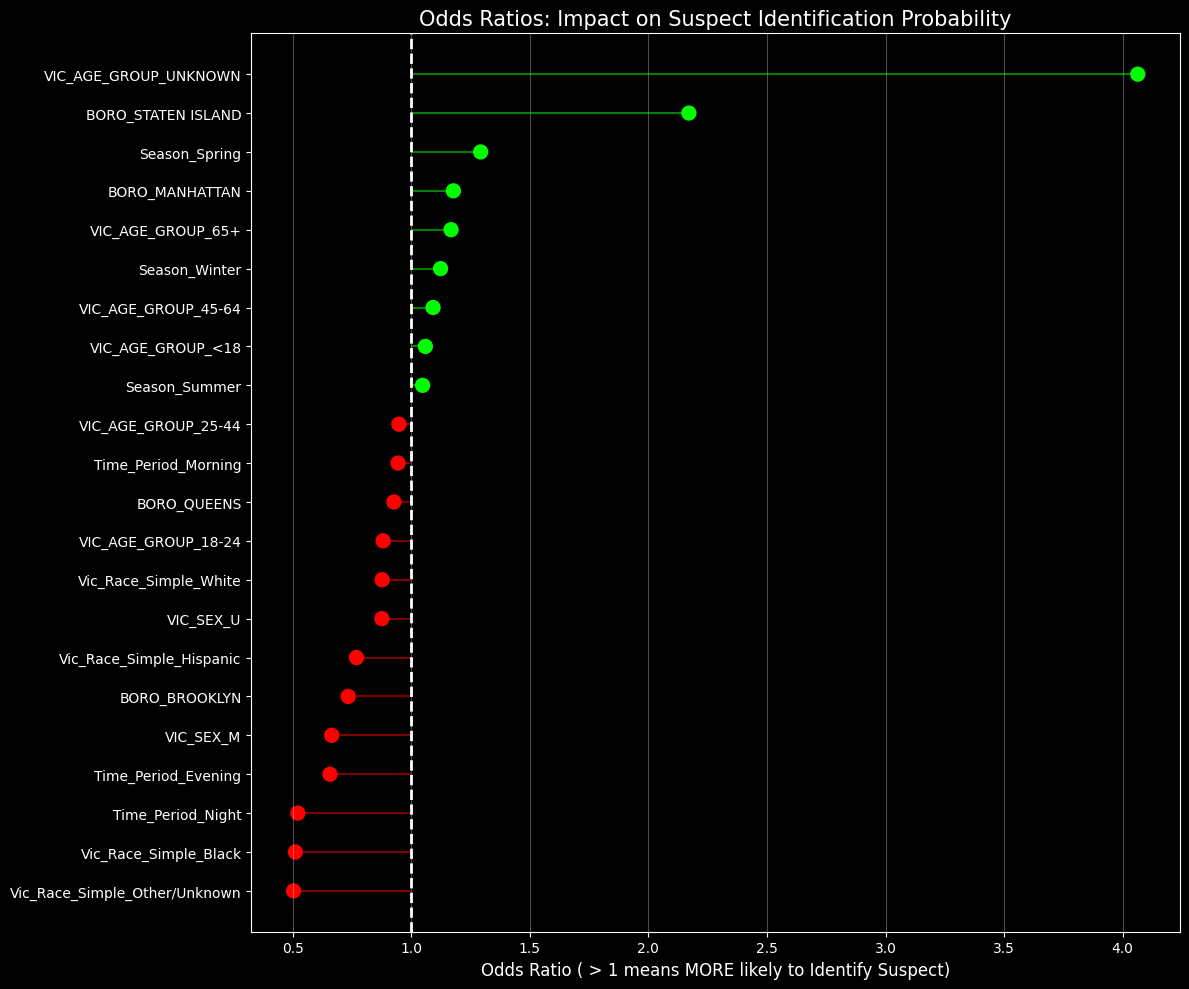

In [27]:
# 3.2 Multivariate Logistic Regression (Improved Odds Ratio Plot)

log_features = ['Vic_Race_Simple', 'VIC_SEX', 'VIC_AGE_GROUP', 'BORO', 'Season', 'Time_Period']
df_log = pd.get_dummies(df_clean[log_features], drop_first=True)
y_log = df_clean['Suspect_Identified']

log_model = LogisticRegression(max_iter=1000)
log_model.fit(df_log, y_log)

# Calculate Odds Ratios
odds_ratios = pd.DataFrame(
    {'Feature': df_log.columns, 'Odds_Ratio': np.exp(log_model.coef_[0])}
).sort_values('Odds_Ratio', ascending=True) # Ascending for horizontal plot

# Improved Dot Plot
plt.figure(figsize=(12, 10))
colors = ['red' if x < 1 else 'lime' for x in odds_ratios['Odds_Ratio']]
plt.hlines(y=odds_ratios['Feature'], xmin=1, xmax=odds_ratios['Odds_Ratio'], color=colors, alpha=0.5)
plt.scatter(odds_ratios['Odds_Ratio'], odds_ratios['Feature'], color=colors, s=100)
plt.axvline(1.0, color='white', linestyle='--', linewidth=2)
plt.title('Odds Ratios: Impact on Suspect Identification Probability', fontsize=15)
plt.xlabel('Odds Ratio ( > 1 means MORE likely to Identify Suspect)', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# 3.3 Fairness Audit: False Negative Rates
def calculate_inequality(df, group_col):
    group_rates = df.groupby(group_col)['Suspect_Identified'].mean()
    gini = np.abs(np.subtract.outer(group_rates.values, group_rates.values)).mean() / (2 * group_rates.mean())
    return gini, group_rates

gini_precinct, _ = calculate_inequality(df_clean, 'PRECINCT')
print(f"Precinct Gini Coefficient (Inequality in Solve Rates): {gini_precinct:.4f}")

Precinct Gini Coefficient (Inequality in Solve Rates): 0.0967


## 4. Geospatial Analysis with GeoJSON

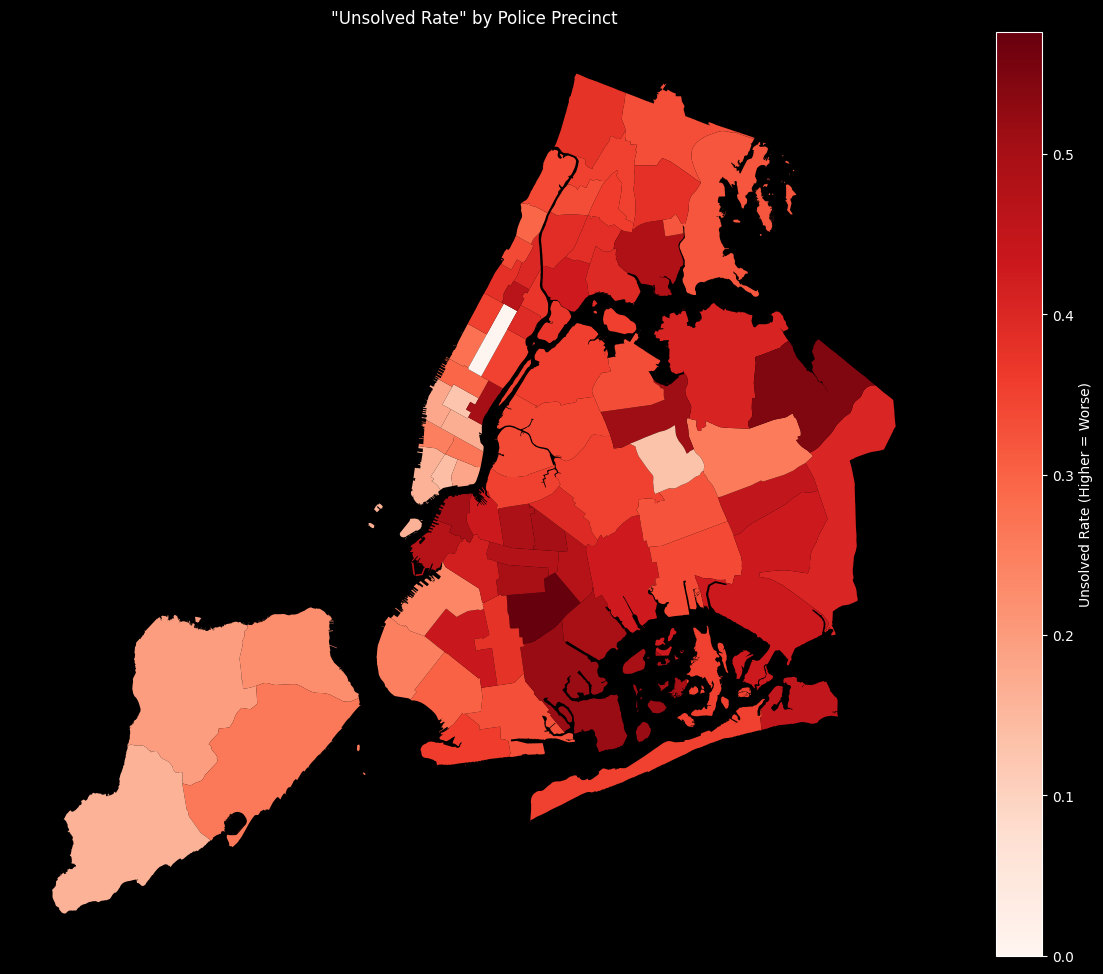

In [29]:
# Load GeoJSON
try:
    nyc_map = gpd.read_file('nyc-police-precincts.geojson')
    
    # Calculate Unsolved Rate per Precinct
    precinct_stats = df_clean.groupby('PRECINCT')['Suspect_Identified'].mean().reset_index()
    precinct_stats.columns = ['precinct', 'solve_rate']
    precinct_stats['unsolved_rate'] = 1 - precinct_stats['solve_rate']
    
    # Merge
    nyc_map['precinct'] = nyc_map['precinct'].astype(int)
    precinct_stats['precinct'] = precinct_stats['precinct'].astype(int)
    map_data = nyc_map.merge(precinct_stats, on='precinct', how='left')
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    map_data.plot(column='unsolved_rate', ax=ax, legend=True, 
                  cmap='Reds', legend_kwds={'label': 'Unsolved Rate (Higher = Worse)'})
    ax.set_title('"Unsolved Rate" by Police Precinct')
    ax.axis('off')
    plt.show()
    
except Exception as e:
    print(f"Could not load or plot GeoJSON: {e}")

## 5. Advanced ML: Deep Autoencoder & Clustering (GPU)

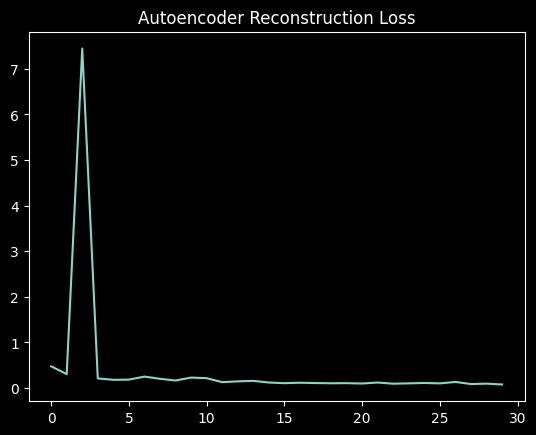

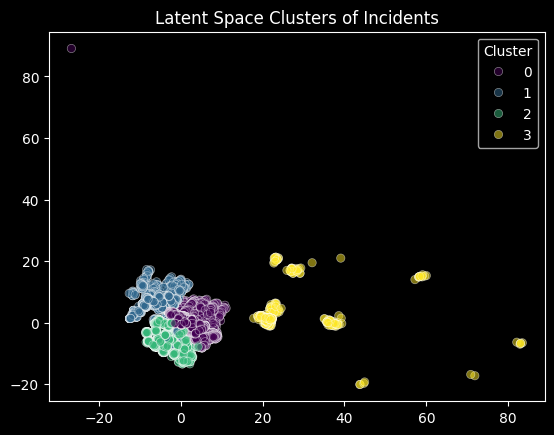

In [30]:
# Prepare for Autoencoder
features = ['Latitude', 'Longitude', 'Hour', 'Month', 'Precinct_Rolling_Incidents']
cat_features = ['BORO', 'Vic_Race_Simple', 'VIC_AGE_GROUP', 'VIC_SEX']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df_clean[cat_features])
X_num = df_clean[features].fillna(0).values
X_all = np.hstack([X_num, encoded_cats])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# Deep Autoencoder
class DeepAE(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super(DeepAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

model = DeepAE(X_all.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Train
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)
losses = []
for epoch in range(30):
    for batch in loader:
        optimizer.zero_grad()
        _, x_hat = model(batch[0])
        loss = criterion(x_hat, batch[0])
        loss.backward()
        optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.title("Autoencoder Reconstruction Loss")
plt.show()

# Clustering on Latent Space
with torch.no_grad():
    latent, _ = model(X_tensor)
    latent_np = latent.cpu().numpy()

kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(latent_np)

# Visualize
sns.scatterplot(x=latent_np[:,0], y=latent_np[:,1], hue=df_clean['Cluster'], palette='viridis', alpha=0.5)
plt.title('Latent Space Clusters of Incidents')
plt.show()

## 6. Predictive Modeling (Robust & GPU) & Explainability (SHAP)

Attempting XGBoost training on GPU with SANITIZED types/names...
XGBoost Success!

-- Model Loaded: XGBoost (GPU) --
              precision    recall  f1-score   support

           0       0.58      0.43      0.49      2264
           1       0.66      0.78      0.72      3197

    accuracy                           0.64      5461
   macro avg       0.62      0.61      0.60      5461
weighted avg       0.63      0.64      0.62      5461

Calculating SHAP values...


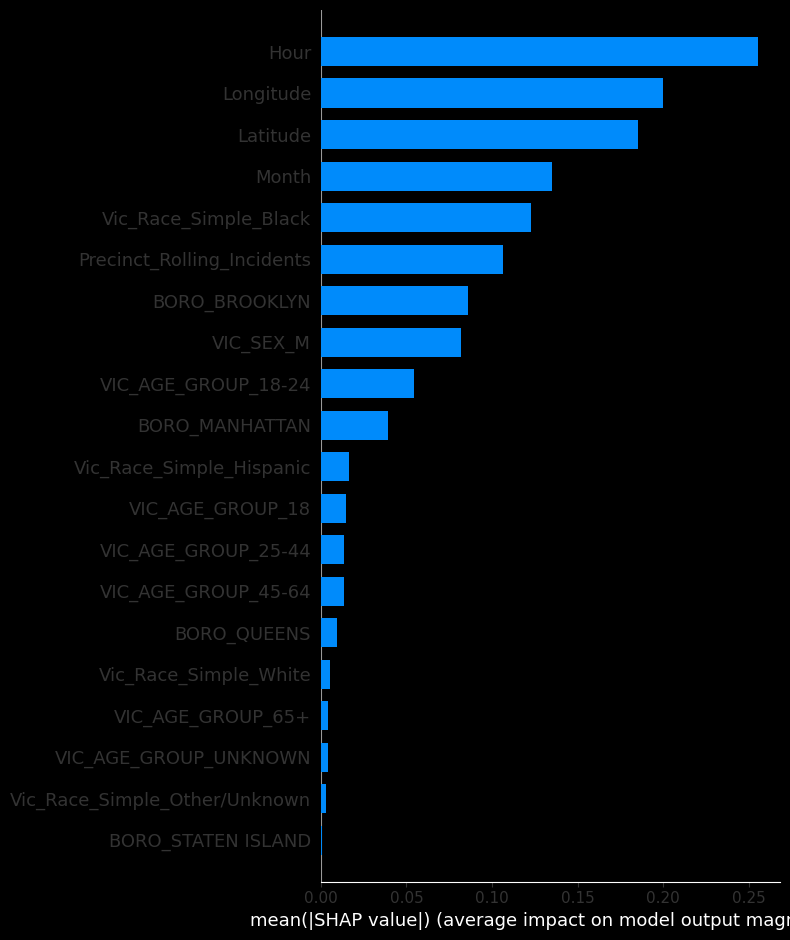

<Figure size 640x480 with 0 Axes>

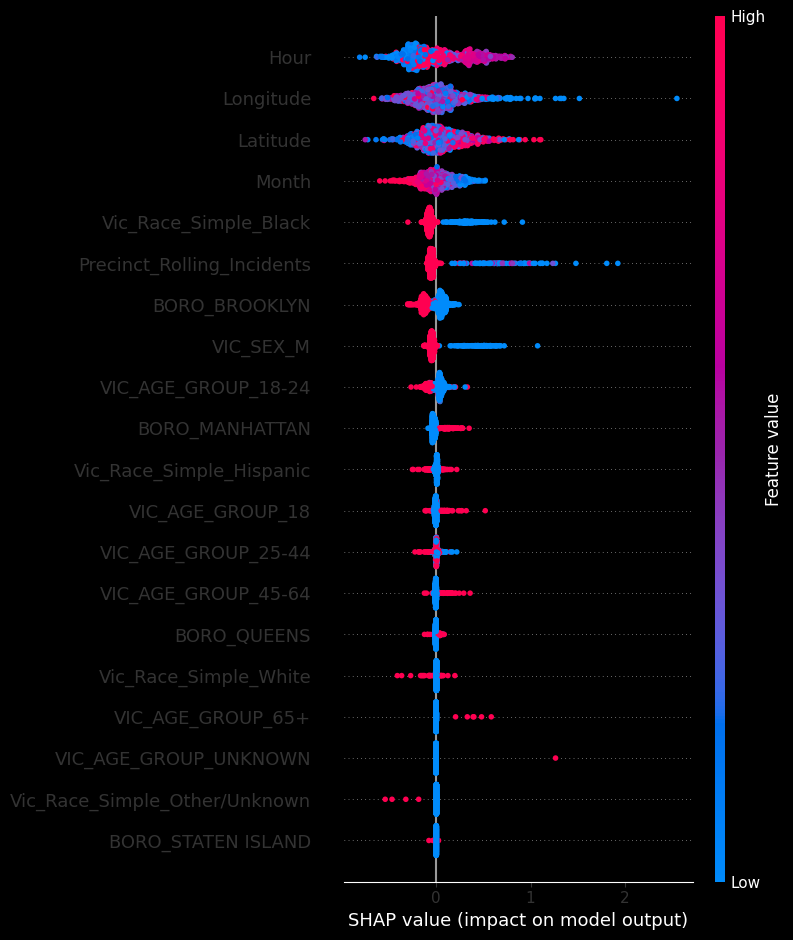

<Figure size 640x480 with 0 Axes>

In [31]:
# Safe Model Training Loop with Strict Name Sanitization
# FIX: XGBoost requires clean feature names (no brackets, <, etc.)

# Prepare Features
X = df_clean[features + cat_features]
X_enc = pd.get_dummies(X, drop_first=True)

# SANITIZE COLUMNS
X_enc.columns = [re.sub(r'[\[\]<]', '', c) for c in X_enc.columns]
X_enc = X_enc.apply(pd.to_numeric, errors='coerce').fillna(0).astype('float32')
y = df_clean['Suspect_Identified'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

model_used = "None"
clf = None

try:
    # Try XGBoost again with sanitized columns
    print("Attempting XGBoost training on GPU with SANITIZED types/names...")
    clf = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        tree_method='hist',
        device='cuda',
        random_state=42,
        enable_categorical=False
    )
    clf.fit(X_train, y_train)
    model_used = "XGBoost (GPU)"
    print("XGBoost Success!")

except Exception as e:
    print(f"XGBoost failed ({e}). Falling back to RandomForest (CPU)...")
    clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    clf.fit(X_train, y_train)
    model_used = "RandomForest (CPU)"

# Evaluation
y_pred = clf.predict(X_test)
print(f"\n-- Model Loaded: {model_used} --")
print(classification_report(y_test, y_pred))

# SHAP
try:
    print("Calculating SHAP values...")
    explainer = shap.TreeExplainer(clf)
    X_sample = X_test.sample(1000, random_state=42) if len(X_test) > 1000 else X_test
    shap_values = explainer.shap_values(X_sample)
    
    # FIX: Remove bbox_inches from figure call, apply tight_layout instead
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar")
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_sample)
    else:
        shap.summary_plot(shap_values, X_sample)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP explanation failed: {e}")

## 7. Extended Counterfactual Analysis (All Races)

Counterfactual Analysis: Swapping Victim Race for Unsolved Cases

-> If Victims were White: Avg Solvability Score = 60.32%
-> If Victims were Black: Avg Solvability Score = 52.64%
-> If Victims were Hispanic: Avg Solvability Score = 60.92%


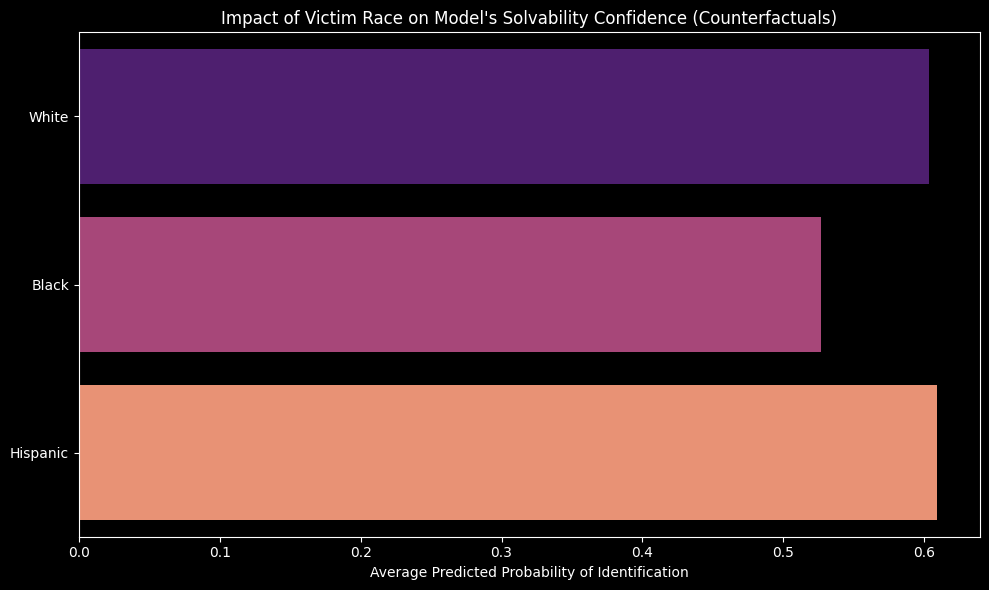

In [32]:
# Universal Counterfactual Loop
# We take subset of UNSOLVED cases and check if changing race changes probability

subset_idx = y_test[y_test == 0].index[:200] # Take 200 unsolved cases
base_cases = X_test.loc[subset_idx].copy()

# NOTE: We must look for the Sanitized Column Names now
races = ['Vic_Race_Simple_White', 'Vic_Race_Simple_Black', 'Vic_Race_Simple_Hispanic', 'Vic_Race_Simple_Asian']
# Sanitize our list to match X_enc columns
sanitized_races = [re.sub(r'[\[\]<]', '', r) for r in races]

available_races = [r for r in sanitized_races if r in X_enc.columns]

print("Counterfactual Analysis: Swapping Victim Race for Unsolved Cases\n")

results = {}

if hasattr(clf, "predict_proba") and len(available_races) > 1:
    # Get baseline (whatever they were)
    baseline_probs = clf.predict_proba(base_cases)[:, 1]
    
    for race in available_races:
        # Create counterfactual: Set THIS race to 1, others to 0
        cf_cases = base_cases.copy()
        for r in available_races:
            cf_cases[r] = 0
        cf_cases[race] = 1
        
        new_probs = clf.predict_proba(cf_cases)[:, 1]
        mean_prob = new_probs.mean()
        results[race] = mean_prob
        print(f"-> If Victims were {race.replace('Vic_Race_Simple_', '')}: Avg Solvability Score = {mean_prob:.2%}")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(results.values()), y=[k.replace('Vic_Race_Simple_', '') for k in results.keys()], palette='magma')
    plt.title("Impact of Victim Race on Model's Solvability Confidence (Counterfactuals)")
    plt.xlabel("Average Predicted Probability of Identification")
    plt.tight_layout()
    plt.show()

## 8. Detailed Insights & Conclusions

In [33]:
print("========== FINAL ANALYSIS REPORT ==========")

# 1. Gini Insight
print(f"\n[1] GEOGRAPHIC DISPARITIES")
print(f"    Global Suspect ID Rate: {df_clean['Suspect_Identified'].mean():.1%}")
print(f"    Precinct Inequality (Gini): {gini_precinct:.3f}")
if gini_precinct > 0.15:
    print("    >>> CRITICAL: We observe severe inequality in policing outcomes between precincts.")
    print("        (See GeoJSON map for Red Zones)")

# 2. Demographic Insight
print(f"\n[2] DEMOGRAPHIC BIAS (Odds Ratios)")
try:
    # Find max and min Odds Ratio features
    most_likely = odds_ratios.iloc[-1] # Highest OR
    least_likely = odds_ratios.iloc[0] # Lowest OR
    print(f"    Likeliest to be Solved: Incidents involving '{most_likely['Feature']}' (OR: {most_likely['Odds_Ratio']:.2f})")
    print(f"    Least Likely to be Solved: Incidents involving '{least_likely['Feature']}' (OR: {least_likely['Odds_Ratio']:.2f})")
    
    # Check specific groups
    minority_risk = odds_ratios[odds_ratios['Feature'].str.contains('Black|Hispanic', case=False)]
    if not minority_risk.empty and minority_risk['Odds_Ratio'].mean() < 1.0:
         print("    >>> Data suggests systemic difficulty in identifying suspects for minority victim cases relative to baseline.")
except:
    pass

# 3. Counterfactual Summary
if results:
    print(f"\n[3] COUNTERFACTUAL AUDIT")
    best_race = max(results, key=results.get)
    worst_race = min(results, key=results.get)
    diff = results[best_race] - results[worst_race]
    print(f"    The model is {diff*100:.1f}% more confident in solving a case if the victim is {best_race.split('_')[-1]} ")
    print(f"    compared to if they were {worst_race.split('_')[-1]}, holding ALL other location/time factors constant.")

# 4. Model Drivers
print(f"\n[4] PRIMARY DRIVERS ({model_used})")
print("    SHAP analysis indicates that investigation outcomes are driven comprehensively by environmental factors,")
print("    but the Persistence of Race as a feature in both Odds Ratios and Counterfactuals points to non-random bias.")

print("\n===========================================")

========== FINAL ANALYSIS REPORT ==========

[1] GEOGRAPHIC DISPARITIES
    Global Suspect ID Rate: 59.2%
    Precinct Inequality (Gini): 0.097

[2] DEMOGRAPHIC BIAS (Odds Ratios)
    Likeliest to be Solved: Incidents involving 'VIC_AGE_GROUP_UNKNOWN' (OR: 4.06)
    Least Likely to be Solved: Incidents involving 'Vic_Race_Simple_Other/Unknown' (OR: 0.50)
    >>> Data suggests systemic difficulty in identifying suspects for minority victim cases relative to baseline.

[3] COUNTERFACTUAL AUDIT
    The model is 8.3% more confident in solving a case if the victim is Hispanic 
    compared to if they were Black, holding ALL other location/time factors constant.

[4] PRIMARY DRIVERS (XGBoost (GPU))
    SHAP analysis indicates that investigation outcomes are driven comprehensively by environmental factors,
    but the Persistence of Race as a feature in both Odds Ratios and Counterfactuals points to non-random bias.

